# Introduction

In the NFL today, most interest is directed toward the offense, even when it comes to advanced analytics. Naturally, we were inspired to complete a study that can benefit the defense while also speaking to what the offense is doing. This study examines how defensive positioning and movement affect yards after catch (YAC) on completed NFL pass plays in the NFL. YAC is a critical component of offensive success, often determining whether a short completion becomes a routine gain or an explosive play. By analyzing player tracking data from the 2023 NFL season, we quantified how close defenders are to receivers at the moment of the catch, understood the likely objective of the defender based on their movement direction and speed, and how these factors influence the likelihood and magnitude of YAC.

In [1]:
library(tidyverse)
library(arrow)
library(ggplot2)
library(dplyr)
library(xgboost)
library(pROC)
library(gganimate)
library(ggtext)
library(tidyr)
library(ggthemes)
library(gtExtras)
library(gt)
library(nflreadr)
options(warn = -1, message = -1)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘arrow’




The following object is masked from ‘package:lubridate’:

    duration




The following object is masked from ‘package:utils’:

    timestamp




...

The following object is masked from ‘package:dplyr’:

    slice




Type 'citation("pROC")' for a citation.




Attaching package: ‘pROC’




The following objects are masked from ‘package:stats’:

    cov, smooth, var




Loading required package: gt



In [2]:
# Read files in

targetdata <- read_parquet("../input/sumersupplement-bdb-26/sumer_bdb/sumer_coverages_player_play.parquet")

supdata <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/supplementary_data.csv")

week1out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w01.csv")
week2out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w02.csv")
week3out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w03.csv")
week4out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w04.csv")
week5out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w05.csv")
week6out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w06.csv")
week7out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w07.csv")
week8out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w08.csv")
week9out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w09.csv")
week10out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w10.csv")
week11out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w11.csv")
week12out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w12.csv")
week13out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w13.csv")
week14out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w14.csv")
week15out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w15.csv")
week16out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w16.csv")
week17out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w17.csv")
week18out <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/output_2023_w18.csv")

week1 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w01.csv")
week2 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w02.csv")
week3 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w03.csv")
week4 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w04.csv")
week5 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w05.csv")
week6 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w06.csv")
week7 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w07.csv")
week8 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w08.csv")
week9 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w09.csv")
week10 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w10.csv")
week11 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w11.csv")
week12 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w12.csv")
week13 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w13.csv")
week14 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w14.csv")
week15 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w15.csv")
week16 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w16.csv")
week17 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w17.csv")
week18 <- read.csv("../input/nfl-big-data-bowl-2026-analytics/114239_nfl_competition_files_published_analytics_final/train/input_2023_w18.csv")

In [3]:
data <- rbind(week1, week2,week3,week4, week5, week6, week7, week8, week9,week10, week11, week12, 
              week13, week14, week15, week16, week17, week18)
outputs <- rbind(week1out,week2out, week3out, week4out, week5out, week6out, week7out, week8out,
                 week9out, week10out, week11out, week12out, week13out, week14out, week15out, week16out,
                 week17out, week18out)

playerinfo <- data %>%
  distinct(game_id, play_id, nfl_id, .keep_all = TRUE) %>%
  select(game_id, play_id, nfl_id, player_name, player_position, player_to_predict, player_side)

outputs <- outputs %>%
  left_join(playerinfo, by = c("game_id", "play_id", "nfl_id"))

To begin our analysis, we wanted to see how gaining YAC affects overall offensive production, using Expected Points Added (EPA). In the bar chart below, we show that plays generating more than four yards of YAC produce meaningfully higher EPA.

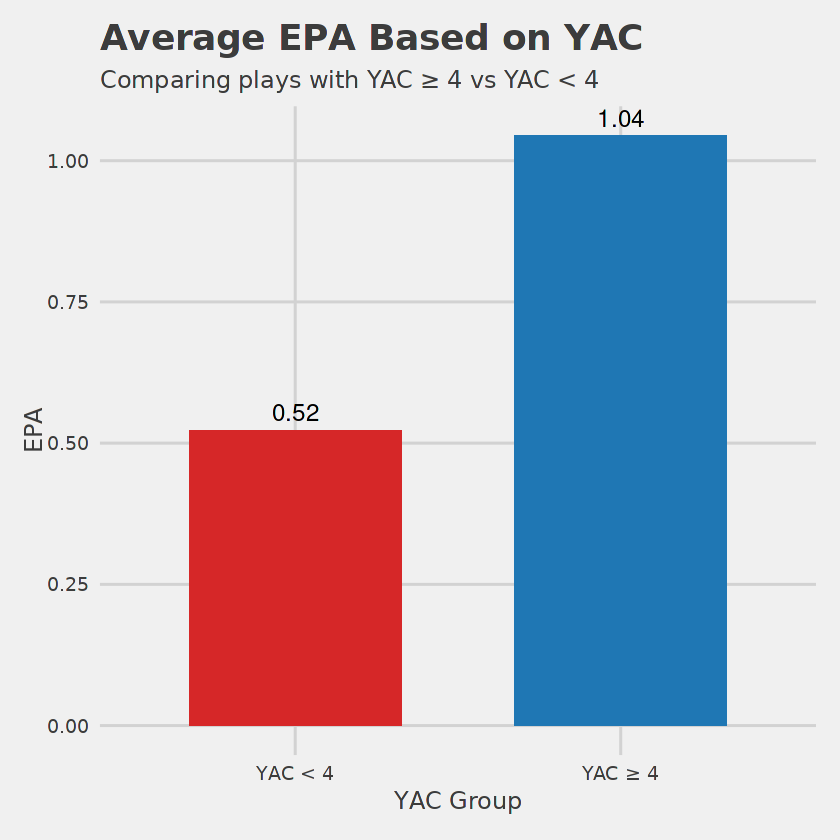

In [4]:
supdata <- supdata %>%
  filter(!grepl("fumble", play_description, ignore.case = TRUE)) %>%
  filter(!grepl("touchdown", play_description, ignore.case = TRUE)) %>%
  filter(pass_result == "C", is.na(penalty_yards))%>%
  mutate(
    yac = yards_gained - pass_length
  ) 
  
first <- supdata %>%
  mutate(
    yac_group = ifelse(yac >= 4, "YAC ≥ 4", "YAC < 4")
  )
epa_summary <- first %>%
  group_by(yac_group) %>%
  summarize(
    mean_EPA = mean(expected_points_added, na.rm = TRUE),
    play_count = n()
  )

ggplot(epa_summary, aes(x = yac_group, y = mean_EPA, fill = yac_group)) +
  geom_col(width = 0.65) +
  geom_text(aes(label = round(mean_EPA, 2)), 
            vjust = -0.5, size = 5) +
  scale_fill_manual(values = c("YAC ≥ 4" = "#1f77b4", "YAC < 4" = "#d62728")) +
  labs(
    title = "Average EPA Based on YAC",
    subtitle = "Comparing plays with YAC ≥ 4 vs YAC < 4",
  ) +
  theme_fivethirtyeight(base_size = 14) +
  theme(axis.title = element_text()) + ylab('EPA') + xlab("YAC Group") +
  theme(legend.position = "none")

To interpret tracking positions, we attached player-level metadata (names, positions, and offensive/defensive side) to each tracking row. We then joined this metadata into the output data, and identified frames that contain only offensive players (where the sum of defense indicators is zero). These purely offensive frames are not relevant for defender–receiver interaction modeling, so we removed them. The resulting data frame contains only frames where at least one defensive player is present.

In [5]:
outputsinfo <- outputs %>%
  group_by(game_id,play_id, frame_id) %>%
  mutate(
    defense = (ifelse(player_side == "Defense", 1, 0))
  ) %>%
  summarise(
    totalDef = sum(defense)
  ) %>%
  filter(totalDef == 0)

outputplays <- outputs %>%
  distinct(game_id, play_id, .keep_all = TRUE)

outputsDef <- outputs %>%
  anti_join(outputsinfo, by = c("game_id", "play_id", "frame_id"))

`summarise()` has grouped output by 'game_id', 'play_id'. You can override
using the `.groups` argument.


The targets variable is constructed by joining the Sumer coverage labels to the tracking input data, which will then allow us to isolate the targeted receiver and their labeled targeted defender for each play.

After ensuring that at each frame of a play we have both the receiver and their coverage defender’s positions, we then compute frame-level spatial features: the distance between the receiver and defender at each frame, and the absolute angular difference between the receiver movement direction and the defender direction.

For each play, we track the last frame’s distance and direction difference, and we retain plays where the final defender–receiver distance is at least two yards, focusing on situations where the defender had meaningful space to close.

In [6]:
targs <- data %>%
  left_join(targetdata, by = c("game_id", "play_id", "nfl_id"))

receivers479 <- targs %>%
  filter(player_role == "Targeted Receiver") %>%
  select(game_id, play_id, frame_id, nfl_id, player_name, x, y, player_position, recDir = dir, ball_land_x, ball_land_y)

# Get defenders at the same frame
defenders479 <- targs %>%
  filter(targeted_defender == TRUE) %>%
  select(game_id, play_id, frame_id, player_name, defenderId = nfl_id, defenderY = y, defenderX = x, player_position, dbDir = dir)

joined479 <- inner_join(receivers479, defenders479, by = c("game_id", "play_id", "frame_id"))

angle_diff <- function(a, b) {
  diff <- abs(a - b) %% 360
  ifelse(diff > 180, 360 - diff, diff)
}

joined479 <- joined479 %>%
  # compute inputDistance per frame
  mutate(inputDistance = sqrt((x - defenderX)^2 + (y - defenderY)^2),
         dirDiff = angle_diff(recDir, dbDir)
  ) %>%
  group_by(game_id, play_id) %>%
  arrange(frame_id, .by_group = TRUE) %>%
  # compute valid flag based on the last frame distance of the play
  mutate(
    lastDistance = last(inputDistance),
    lastdirDiff = last(dirDiff),
    valid = ifelse(lastDistance >= 2,1, 0)
  ) %>%
  ungroup() %>%
  filter(valid == 1)

dirDiffs <- joined479 %>%
  distinct(game_id, play_id, .keep_all = TRUE) %>%
  select(game_id, play_id, lastdirDiff)
  
outputs479 <- outputsDef %>%
  semi_join(joined479, by = c("game_id", "play_id"))

receiversoutputs479 <- outputs479 %>%
  filter(player_position %in% c("RB", "WR", "TE")) %>%
  select(game_id, play_id, frame_id, nfl_id, player_name, x, y, player_position)

# Get defenders at the same frame
defendersoutputs479 <- outputs479 %>%
  filter(player_position %in% c("CB", "SS","FS", "DB", "ILB", "LB", "MLB")) %>%
  select(game_id, play_id, frame_id, player_name, defenderId = nfl_id, defenderY = y, defenderX = x, player_position)

joinedoutputs479 <- inner_join(receiversoutputs479, defendersoutputs479, by = c("game_id", "play_id", "frame_id"))


joinedoutputs479 <- joinedoutputs479 %>%
  left_join(targetdata, by = c("game_id", "play_id", "defenderId" = "nfl_id"))

joinedoutputs479 <- joinedoutputs479 %>%
  filter(targeted_defender == "TRUE")

multi_defender_plays <- joinedoutputs479 %>%
  group_by(game_id, play_id, nfl_id) %>%        # group by play + receiver
  summarise(num_defenders = n_distinct(defenderId), .groups = "drop") %>%
  filter(num_defenders > 1)

joinedoutputs479 <- joinedoutputs479 %>%
  anti_join(multi_defender_plays,
            by = c("game_id", "play_id", "nfl_id"))

To relate defender proximity to offensive production, we took the last tracking frame for the targeted receiver–defender pair. We then joined in play-level information and construct the response variables: YAC (defined as yards gained - pass length for completed passes) and the distance between the defender and the receiver in the last frame. 

We focused only on completed passes, plays without called penalties, plays without fumbles, and passes with air yards no more than 20 and final distances less than 40 yards. As a baseline, we fit a simple linear regression of YAC on the final distance and visualize the relationship. This provides a baseline measure of how separation at the catch correlates with YAC before introducing more complex movement features.

In [7]:
final_frame_df <- joinedoutputs479 %>%
  group_by(game_id, play_id) %>%
  slice_max(order_by = frame_id, n = 1, with_ties = FALSE) %>%
  ungroup()

distances <- final_frame_df %>%
  left_join(supdata, by = c("game_id", "play_id"))

distances <- distances %>%
  filter(!grepl("fumble", play_description, ignore.case = TRUE)) %>%
  filter(pass_result == "C", is.na(penalty_yards))%>%
  mutate(
    yac = yards_gained - pass_length,
    final_distance = sqrt((x - defenderX)^2 +
                            (y - defenderY)^2)
  ) %>%
  filter(final_distance < 40, pass_length <= 20)


observe <- distances %>%
  select(player_name.x, player_name.y, x, y, defenderX, defenderY, yac, final_distance, )

![Relationship Between Defender Distance at Final Frame and YAC](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19450357%2Fe9d5be02ac734735bf5daac094b0c43b%2FRelationship%20defender%20yac.png?generation=1765930564776214&alt=media)

Before building our more complex model, we briefly compared the targeted defender labels to a simple heuristic definition based on tracking data. This is to assesses whether a proximity-based assignment aligns with expert coverage labels and demonstrates that the labels from Sumer Sports capture more than just who is closest to the ball. The output shows us that the two agree 83% of the time, making it a fair assumption to make.

In [8]:
outputs_updated_frames = outputs %>% mutate(frame_id = frame_id+100)

output_players = outputs_updated_frames %>% select(game_id,play_id,nfl_id) %>% distinct()

data_only_in_out = data %>% 
  semi_join(output_players, by = c("game_id","play_id","nfl_id"))


joined_distances = rbind(select(data_only_in_out,colnames(outputs_updated_frames)),outputs_updated_frames)

ball_land = data %>% 
  select(game_id,play_id,ball_land_x,ball_land_y) %>% 
  distinct()

joined_distances = joined_distances %>% 
  left_join(ball_land,by = c("game_id","play_id")) %>% 
  mutate(distance_ball = sqrt((x - ball_land_x)^2 + (y - ball_land_y)^2)) 

target_defender = joined_distances %>% 
  filter(player_side == "Defense") %>% 
  group_by(game_id, play_id,nfl_id) %>%
  slice_max(order_by = frame_id, n = 1, with_ties = FALSE) %>%
  ungroup() %>% 
  group_by(game_id, play_id) %>% 
  slice_max(order_by = -distance_ball, n=1,with_ties = FALSE) %>% 
  ungroup() %>% 
  select(game_id,play_id,nfl_id) %>% 
  mutate(dist = TRUE)

player_names = data_only_in_out %>% 
  select(nfl_id,player_name,player_position) %>% 
  distinct()

select_distances = joined_distances %>% 
  filter(player_side == "Defense") %>% 
  group_by(game_id, play_id,nfl_id) %>%
  slice_max(order_by = frame_id, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(game_id,play_id,nfl_id, distance_ball)


sumer_targ_def = targetdata %>% 
  filter(targeted_defender) %>% 
  select(game_id,play_id,nfl_id) %>% 
  mutate(sumer = TRUE)

targeted_distance_vs_sumer = target_defender %>% 
  full_join(sumer_targ_def, by = c("game_id","play_id","nfl_id")) %>%
  left_join(player_names, by = "nfl_id") %>% 
  left_join(select_distances, by = c("game_id","play_id","nfl_id")) %>% 
  mutate(sumer = replace_na(sumer, FALSE), dist = replace_na(dist,FALSE)) %>% 
  arrange(game_id, play_id, nfl_id)

summarise(targeted_distance_vs_sumer, sumer = mean(sumer), dist = mean(dist))

sumer,dist
<dbl>,<dbl>
0.8286934,0.8260177


Static distance at the catch only captures part of the story. To incorporate defender movement, we computed the distance from the defender to the receiver and the distance from the defender to the ball landing point for each frame. We derived two different closing rates, one for moving towards the receiver and one for moving towards the ball. If the closing rate is positive, that means that the defender is moving closer. We defined a binary target variable (1 if YAC was 4 yards or more, 0 if not) and retrieved the direction of the defender’s velocity vector, the angle from the defender to the receiver, and the difference between the defender’s motion direction and the line to the receiver. We selected only plays with at least five frames, focusing on defender behavior immediately prior to and around the catch.

In [9]:
#distance to receiver

joinedoutputs479 <- joinedoutputs479 %>%
  left_join(ball_land, by = c("game_id", "play_id"))
joinedoutputs479 <- joinedoutputs479 %>%
  group_by(game_id, play_id) %>%
  mutate(
    distanceReceiver = sqrt((defenderX - x)^2 + (defenderY - y)^2),
    distanceBall = sqrt((defenderX - ball_land_x)^2 + (defenderY - ball_land_y)^2)
  )
#instantaneous velocity towards receiver vs towards ball at each frame calculated in ROC's
#feel free to double check this calculation
ROCs <- joinedoutputs479 %>%
  group_by(game_id, play_id, defenderId) %>%
  mutate(
    close_rec_inst = (distanceReceiver - lead(distanceReceiver)) / 0.1,
    close_ball_inst = (distanceBall - lead(distanceBall)) / 0.1,
    
    close_rec_inst = ifelse(is.infinite(close_rec_inst) | is.nan(close_rec_inst), NA, close_rec_inst),
    close_ball_inst = ifelse(is.infinite(close_ball_inst) | is.nan(close_ball_inst), NA, close_ball_inst)
  )

ROCjoined <- ROCs %>%
  left_join(distances, by = c("game_id", "play_id")) %>%
  filter(!is.na(yards_to_go)) %>%
  mutate(
    target = ifelse(yac >= 4, 1, 0),
    angle_def_vel = atan2((lead(defenderY.x) - defenderY.x) / 0.1, (lead(defenderX.x) - defenderX.x) / 0.1),
    angle_def_to_rec = atan2(y.x - defenderY.x, x.x - defenderX.x),
    angle_diff = atan2(sin(angle_def_vel - angle_def_to_rec), cos(angle_def_vel - angle_def_to_rec))
  ) 

ROC5 <- ROCjoined %>%
  arrange(game_id, play_id, frame_id.x) %>%
  group_by(game_id, play_id) %>%
  filter(n() >= 5) %>%
  slice_tail(n = 5) %>%
  ungroup()
 
str(ROCjoined$game_id)
str(ROCjoined$play_id)



ROC5 <- ROC5 %>%
  left_join(dirDiffs, by = c("game_id", "play_id"))

unique_plays <- ROC5 %>% 
  distinct(game_id, play_id) %>%
  ungroup()

 int [1:45390] 2023090700 2023090700 2023090700 2023090700 2023090700 2023090700 2023090700 2023090700 2023090700 2023090700 ...


 int [1:45390] 219 219 219 219 219 219 219 219 361 361 ...


# Modeling

To model the probability of generating meaningful YAC, we trained an XGBoost classification model using these spatial and motion-based features. Our results showed that a defender’s closing speed, final separation distance, and directional alignment are among the most influential predictors of YAC outcomes. We also estimated a regression model to explain actual YAC using the model’s predicted probabilities along with situational football variables such as down, yards to go, pass length, and coverage type. The results confirm that defensive proximity and movement significantly impact post-catch production even after considering situational context.

We used the following frame-level features to train the model: the closing rate toward the receiver, the closing rate toward the ball, the final defender–receiver separation,  the distance to the receiver in the late frames, the final direction difference between receiver and defender.

After filtering out rows with missing closing rates, we transformed these predictors into model matrices and fit a gradient boosted tree model with a logistic loss. The model was trained for up to 300 rounds with early stopping based on validation log-loss.

In [10]:
set.seed(2015)

train_plays <- unique_plays %>% 
  sample_frac(0.8)  

test_plays <- anti_join(unique_plays, train_plays,
                        by = c("game_id", "play_id"))

train_df <- ROC5 %>% 
  inner_join(train_plays, by = c("game_id", "play_id"))

play <- train_df %>%
  filter(game_id == 2023102201, play_id == 485)
train_df <- train_df %>%
  filter(!(game_id == 2023102201 & play_id == 485))

test_df <- ROC5 %>% 
  inner_join(test_plays, by = c("game_id", "play_id"))

test_df <- rbind(test_df, play)


features <- c("close_rec_inst", "close_ball_inst", "final_distance", "distanceReceiver", "lastdirDiff")

train_df <- train_df %>%
  filter(!is.na(close_rec_inst), !is.na(close_ball_inst))

test_df <- test_df %>%
  filter(!is.na(close_rec_inst), !is.na(close_ball_inst))


train_matrix <- model.matrix(~ . - 1, data = train_df[, features])
test_matrix  <- model.matrix(~ . - 1, data = test_df[, features])

dtrain <- xgb.DMatrix(train_matrix, label = train_df$target)
dtest  <- xgb.DMatrix(test_matrix,  label = test_df$target)

params <- list(
  objective = "binary:logistic",
  eval_metric = "logloss",
  max_depth = 4,
  eta = 0.1,
  subsample = 0.8,
  colsample_bytree = 0.8
)

model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = 300,
  watchlist = list(train = dtrain, test = dtest),
  print_every_n = 50,
  early_stopping_rounds = 20
)

test_df$pred_prob <- predict(model, dtest)

check <- test_df %>%
  filter(game_id == 2023102201, play_id == 485)

[1]	train-logloss:0.668963	test-logloss:0.670919 
Multiple eval metrics are present. Will use test_logloss for early stopping.
Will train until test_logloss hasn't improved in 20 rounds.

[51]	train-logloss:0.498056	test-logloss:0.540011 
Stopping. Best iteration:
[52]	train-logloss:0.497565	test-logloss:0.539890



On the test set, we computed the predicted probability that each frame produces high YAC. We evaluate the classifier using the ROC curve and AUC to assess how accurately the model discriminates between YAC vs no YAC plays, and Brier score to capture overall calibration. The model achieved a 0.765 AUC, with a 0.18 Brier Score. Furthermore, we chose to compare the final frame prediction to what actually happened on the play to see how well our model classifies the likelihood of significant YAC being achieved, which achieved a Brier Score of 0.177. We found these results to be acceptable given the nature of YAC and how it can be achieved in spite of ideal defender movement to play the ball. XGBoost’s built-in feature importance summarizes which predictors contribute most to the model’s decisions. The resulting importance plot highlights whether dynamic motion (closing speed), static separation, or directional alignment plays the largest role in predicting YAC. We see that our model is more driven by the rate at which the defender closes on the receiver rather than the rate at which they close on the ball. This makes intuitive sense, considering that YAC can be minimized when DBs are “playing” the receiver compared to playing the ball.

Setting levels: control = 0, case = 1



Setting direction: controls < cases



Area under the curve: 0.7622


[1] 0.1810189

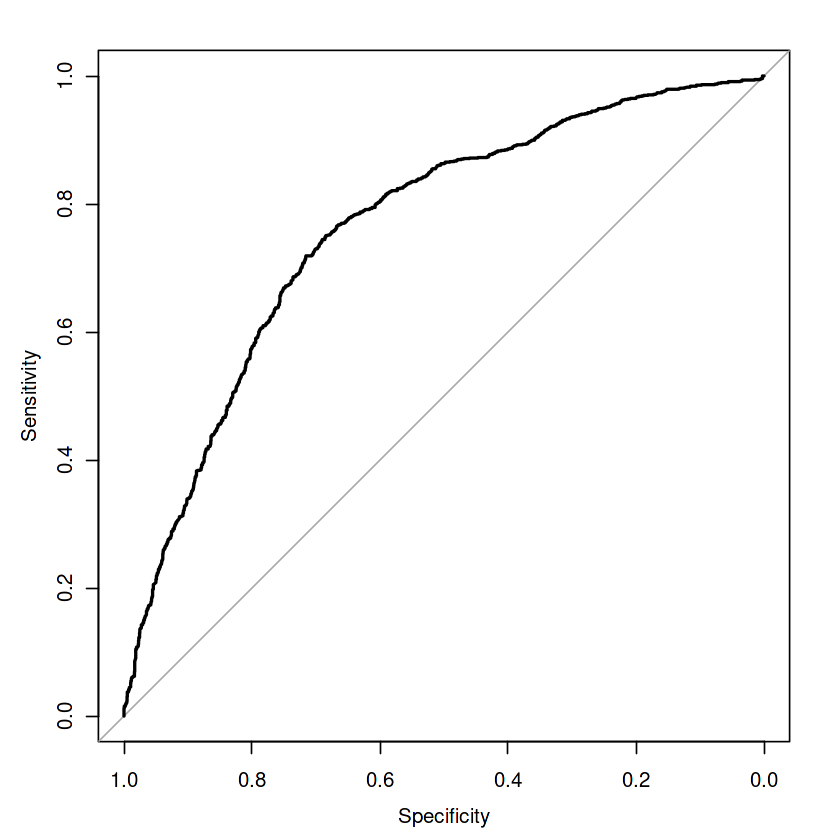

`summarise()` has grouped output by 'game_id', 'play_id'. You can override
using the `.groups` argument.


[1] 0.1781577

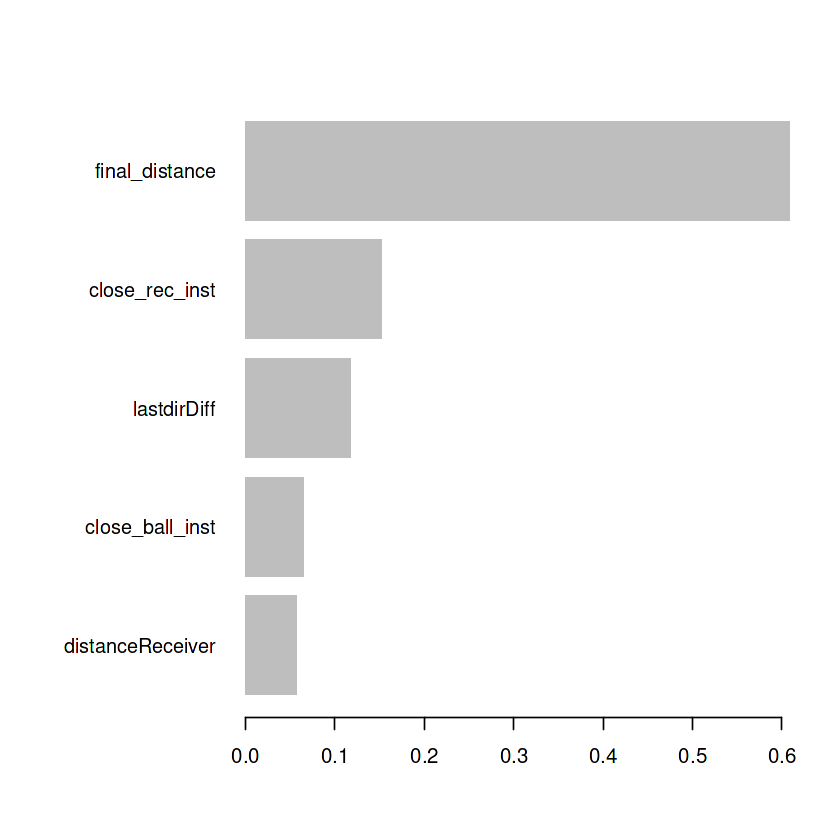

In [11]:
true_y <- test_df$target
roc_obj <- roc(test_df$target, test_df$pred_prob)
print(roc_obj$auc)
plot(roc_obj)


brier <- mean((test_df$pred_prob - true_y)^2)
brier

xgb.importance(feature_names = colnames(train_matrix), model = model) %>%
  xgb.plot.importance(top_n = 10)

play_swings <- test_df %>%
  group_by(game_id, play_id) %>%
  arrange(frame_id.x, .by_group = TRUE) %>%
  summarise(
    start_prob = first(pred_prob),
    end_prob   = last(pred_prob),
    delta_prob = end_prob - start_prob,
    abs_delta  = abs(end_prob - start_prob),
    target = target
  )

last_frame_test <- test_df %>%
  group_by(game_id, play_id) %>%
  arrange(frame_id.x, .by_group = TRUE) %>%
  slice_tail(n = 1) %>%   # keep only the last frame
  ungroup()
brier_score <- mean((last_frame_test$pred_prob - last_frame_test$target)^2)
brier_score

# Result Visualization

To visualize our results, we took a play from the Bears vs Raiders game in Week 7 of 2023 to see how a defender truly affected the likelihood of YAC on a play.

In [12]:
one_play_in = data %>% 
  filter(game_id == 2023102201, play_id == 485) %>% 
  select(colnames(outputs))
frames = max(one_play_in$f)
one_play_out = outputs %>% 
  filter(game_id == 2023102201, play_id == 485) %>% 
  mutate(frame_id = frame_id+frames)
one_play = rbind(one_play_in,one_play_out) %>% 
  mutate(x = x, y = y)

sup = supdata %>% 
  filter(game_id == 2023102201, play_id == 485)

ball = data %>% 
  filter(game_id == 2023102201, play_id == 485) %>% 
  select(ball_land_x, ball_land_y) %>% 
  distinct()

players_out = one_play_out %>% 
  select(nfl_id) %>% 
  distinct()

players_in = one_play %>% 
  filter(!nfl_id %in% players_out) %>% 
  select(nfl_id) %>% 
  distinct()

one_p_players = one_play %>% 
  semi_join(players_out, by = "nfl_id")

filled_in = one_play %>% 
  mutate(alpha = 1) %>% 
  group_by(nfl_id) %>%
  complete(frame_id = full_seq(1:41, 1)) %>%     # ensure every id has frame_id 1–41
  mutate(
    alpha = if_else(is.na(alpha), 0, alpha)  # missing (new) rows become 0.5
  ) %>%
  filter(nfl_id == 55998 | nfl_id == 47862 ) %>%
  fill(everything(), .direction = "down") %>%     # fill missing rows using last known data
  ungroup()

play_data <- ROCjoined %>%
  filter(game_id == 2023102201, play_id == 485) %>%
  left_join(dirDiffs, by = c("game_id", "play_id"))

play_data <- play_data %>% arrange(frame_id.x)

play_data <- play_data %>%
  arrange(frame_id.x) %>%
  mutate(
    dx = c(0, diff(defenderX.x)),
    dy = c(0, diff(defenderY.x)),
    distance = sqrt(dx^2 + dy^2)
  )

avg_speed <- mean(play_data$distance[-1], na.rm = TRUE) # skip first row (0)


vec_x <- play_data$ball_land_x - play_data$defenderX.x[1]
vec_y <- play_data$ball_land_y - play_data$defenderY.x[1]
total_dist <- sqrt(vec_x^2 + vec_y^2)

# Number of frames needed to match actual speed
n_frames_needed <- ceiling(total_dist / avg_speed)

# Recreate straight-line path with realistic speed
straight_line_scaled <- data.frame(
  frame_id = seq(min(play_data$frame_id.x), length.out = n_frames_needed),
  defenderX_alt = play_data$defenderX.x[1] + seq(0, 1, length.out = n_frames_needed) * vec_x,
  defenderY_alt = play_data$defenderY.x[1] + seq(0, 1, length.out = n_frames_needed) * vec_y
) 

straight_line_scaled <- straight_line_scaled %>%
  filter(frame_id <= 10)

AltCheck <- play_data %>%
  left_join(straight_line_scaled, by = c( "frame_id.x" = "frame_id"))

AltCheck <- AltCheck %>%
  group_by(game_id, play_id) %>%
  mutate(
    distanceReceiverAlt = sqrt((defenderX_alt - x.x)^2 + (defenderY_alt - y.x)^2),
    final_distanceAlt = sqrt((defenderX_alt[10] - x.x[10])^2 + (defenderY_alt[10] - y.x[10])^2),
    distanceBallAlt = sqrt((defenderX_alt - ball_land_x)^2 + (defenderY_alt - ball_land_y)^2)
  )
#instantaneous velocity towards receiver vs towards ball at each frame calculated in ROC's
#feel free to double check this calculation
AltCheck <- AltCheck %>%
  group_by(game_id, play_id, defenderId.x) %>%
  mutate(
    close_rec_instAlt = (distanceReceiverAlt - lead(distanceReceiverAlt)) / 0.1,
    close_ball_instAlt = (distanceBallAlt - lead(distanceBallAlt)) / 0.1,
    
    close_rec_instAlt = ifelse(is.infinite(close_rec_inst) | is.nan(close_rec_inst), NA, close_rec_inst),
    close_ball_instAlt = ifelse(is.infinite(close_ball_inst) | is.nan(close_ball_inst), NA, close_ball_inst)
  ) %>%
  ungroup()

OutputCheck <- AltCheck %>%
  filter(frame_id.x >= 6, frame_id.x <= 9)

dmat_actual <- xgb.DMatrix(
  data = as.matrix(OutputCheck %>% select(close_rec_inst = close_rec_instAlt, close_ball_inst = close_ball_instAlt, final_distance = final_distanceAlt, distanceReceiver = distanceReceiverAlt, lastdirDiff))
)
features <- c("close_rec_inst", "close_ball_inst", "final_distance", "distanceReceiver", "lastdirDiff")


pred_alt <- predict(model, dmat_actual)

OutputCheck <- cbind(OutputCheck, pred_alt)
GraphCheck <- cbind(OutputCheck, check$pred_prob)

prob_plot <- GraphCheck %>%
  select(frame_id.x, pred_prob = `check$pred_prob`, pred_alt) %>%
  tidyr::pivot_longer(
    cols = c(pred_prob, pred_alt),
    names_to = "path",
    values_to = "prob"
  ) %>%
  mutate(
    path = factor(path,
                  levels = c("pred_prob", "pred_alt"),
                  labels = c("Actual Path", "Alternative Path"))
  )

![Probability Plot](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19450357%2F6438b7da25b9de948ecc96a8dd5b350f%2FProb%20Plot.png?generation=1765579023895483&alt=media)

![Targeted Play](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F17301853%2F607447a6e92e2de9269d6b759dd6f247%2FPlay.gif?generation=1766015395395630&alt=media)

In this play, the red dot represents WR Tyler Scott from the Bears, while the black dot represents CB David Long from the Raiders. Scott runs a simple dig route while Long defends in man coverage. At the time of the throw (vertex of red path and dotted blue line), Long takes a few frames to realign his hips and angle himself towards Scott, but does this behind the receiver. Fortunately for Long, the ball is underthrown, and Scott is forced to readjust to eventually catch the ball. Because of this readjustment and Long placing himself behind Scott, he is able to reduce the likelihood of YAC from 41% to 25% over the last 5 frames of the play, forcing less than 4 yards of YAC after the Scott jumps to grab the ball. While Long happened to be in the right spot because he played the receiver, could he have played the dig “better” to minimize YAC? 

The blue dotted path shows where Long could have ended up had he moved under the same speed but directly towards the ball. This trajectory would have actually led to a slightly higher chance of YAC throughout the last few frames, starting out a 44% probability of YAC, and eventually going down to 26% by the end of the play. Long would have played the ball in this case, and because of the underthrow would have ended up right at the catchpoint. Undercutting the receiver here leaves the YAC up to chance, whereas the path Long actually took allows him to immediately tackle Scott as soon as the catch is made. It is important to note that this would be the optimal path, and a challenging trajectory considering where his hips were facing and the difficulty of readjusting his hips and immediately breaking towards the ball. While playing the receiver worked out in this case for Long, had there not been an underthrow and the ball ended up in stride for Scott, this play could have generated considerable YAC.

# Player Evaluation

We can also use this model for player evaluation. How well do defenders minimize the chance of YAC throughout a play? How do receivers gain YAC, given the chance of it occurring on the play based on the tracking data? The following leaderboards show the top defensive players that decrease the chance of YAC throughout a play (starting frame probability of YAC - last frame probability of YAC), as well as receivers that gained YAC the most often given the chance of it happening on a certain play.



In [13]:
rosters <- load_rosters(seasons = 2023)
teams <- load_teams()
players_swings <- play_swings %>%
  left_join(test_df, by = c("game_id", "play_id")) %>%
  distinct(game_id, play_id,  .keep_all = TRUE) %>%
  mutate(yacoe = target.x - end_prob)

player_results <- players_swings %>%
  group_by(player_name.y.y, player_position.y.x, defensive_team) %>%
  summarise(
    totalMinimized = sum(delta_prob),
    epa = sum(expected_points_added),
    plays = n()
  ) %>%
  mutate(
    ProbMinimizedPlay = totalMinimized/plays,
    epaperplay = epa/plays
  ) %>%
  ungroup() %>%
  filter(plays >= 5)

off_results <- players_swings %>%
  group_by(player_name.x.x, player_position.x.x, possession_team) %>%
  summarise(
    totalOverExpected = sum(yacoe),
    totalYac = sum(yac),
    epa = sum(expected_points_added),
    plays = n()
  ) %>%
  mutate(
    OEPlay = totalOverExpected/plays,
    epaperplay = epa/plays
  ) %>%
  ungroup() %>%
  filter(plays >= 5)

off_results$player_name.x.x[off_results$player_name.x.x == "Deebo Samuel Sr."] <- "Deebo Samuel"
off_results$player_name.x.x[off_results$player_name.x.x == "Chris Godwin Jr."] <- "Chris Godwin"
off_results$player_name.x.x[off_results$player_name.x.x == "DJ Moore"] <- "D.J. Moore"
player_results$player_name.y.y[player_results$player_name.y.y == "Kenny Moore II"] <- "Kenny Moore"

player_results <- player_results %>%
  left_join(rosters, by = c("player_name.y.y" = "full_name")) %>%
  left_join(teams, by = c("defensive_team" = "team_abbr"))

off_results <- off_results %>%
  left_join(rosters, by = c("player_name.x.x" = "full_name")) %>%
  left_join(teams, by = c("possession_team" = "team_abbr"))

corners <- player_results %>%
  filter(player_position.y.x == "CB") %>%
  dplyr::select(
    player_name.y.y,
    headshot_url,
    team_logo_espn,
    plays,
    epaperplay,
    totalMinimized,
    ProbMinimizedPlay
  ) %>%
  mutate(
    epaperplay = round(epaperplay, 2)
  ) %>%
  arrange((ProbMinimizedPlay)) %>%
  slice_head(n=10) %>%
  gt() %>%
  cols_align(align = "center") %>%
  cols_label(
    player_name.y.y = "Name",
    headshot_url = "",
    team_logo_espn = "Team",
    plays = "Targets",
    epaperplay = "EPA/Target",
    totalMinimized = "YAC Prob. Delta",
    ProbMinimizedPlay = "YAC Prob. Delta/Play"
  ) %>%
  tab_header(
    title = "Top 10 CB's by YAC Probability Delta",
    subtitle = "YAC Probability Delta - Change in Probability of YAC from First Frame To Last Frame"
  ) %>%
  opt_table_font(
    font = list(
      google_font("Chivo"),
      default_fonts()
    )
  ) %>%
  data_color(
    columns = c(ProbMinimizedPlay),
    colors = scales::col_numeric(
      palette = c("#C5050C", "#FFFFFF"),
      domain = NULL
    )
  ) %>%
  fmt_percent(
    columns = c(totalMinimized),
    decimals = 1
  ) %>%
  fmt_percent(
    columns = (ProbMinimizedPlay),
    decimals = 1
  )
corners <- gt_img_rows(corners, column = "headshot_url")
corners <- gt_img_rows(corners, column = "team_logo_espn")


safeties <- player_results %>%
  filter(player_position.y.x == "SS" | player_position.y.x == "FS") %>%
  dplyr::select(
    player_name.y.y,
    headshot_url,
    team_logo_espn,
    plays,
    epaperplay,
    totalMinimized,
    ProbMinimizedPlay
  ) %>%
  mutate(
    epaperplay = round(epaperplay, 2)
  ) %>%
  arrange((ProbMinimizedPlay)) %>%
  slice_head(n=10) %>%
  gt() %>%
  cols_align(align = "center") %>%
  cols_label(
    player_name.y.y = "Name",
    headshot_url = "",
    team_logo_espn = "Team",
    plays = "Targets",
    epaperplay = "EPA/Target",
    totalMinimized = "YAC Prob. Delta",
    ProbMinimizedPlay = "YAC Prob. Delta/Play"
  ) %>%
  tab_header(
    title = "Top 10 SAF's by YAC Probability Delta",
    subtitle = "YAC Probability Delta - Change in Probability of YAC from First Frame To Last Frame"
  ) %>%
  opt_table_font(
    font = list(
      google_font("Chivo"),
      default_fonts()
    )
  ) %>%
  data_color(
    columns = c(ProbMinimizedPlay),
    colors = scales::col_numeric(
      palette = c("#C5050C", "#FFFFFF"),
      domain = NULL
    )
  ) %>%
  fmt_percent(
    columns = c(totalMinimized),
    decimals = 1
  ) %>%
  fmt_percent(
    columns = (ProbMinimizedPlay),
    decimals = 1
  )
safeties <- gt_img_rows(safeties, column = "headshot_url")
safeties <- gt_img_rows(safeties, column = "team_logo_espn")


linebackers <- player_results %>%
  filter(player_position.y.x == "ILB" | player_position.y.x == "MLB") %>%
  dplyr::select(
    player_name.y.y,
    headshot_url,
    team_logo_espn,
    plays,
    epaperplay,
    totalMinimized,
    ProbMinimizedPlay
  ) %>%
  mutate(
    epaperplay = round(epaperplay, 2)
  ) %>%
  arrange((ProbMinimizedPlay)) %>%
  slice_head(n=10) %>%
  gt() %>%
  cols_align(align = "center") %>%
  cols_label(
    player_name.y.y = "Name",
    headshot_url = "",
    team_logo_espn = "Team",
    plays = "Targets",
    epaperplay = "EPA/Target",
    totalMinimized = "YAC Prob. Delta",
    ProbMinimizedPlay = "YAC Prob. Delta/Play"
  ) %>%
  tab_header(
    title = "Top 10 LB's by YAC Probability Delta",
    subtitle = "YAC Probability Delta - Change in Probability of YAC from First Frame To Last Frame"
  ) %>%
  opt_table_font(
    font = list(
      google_font("Chivo"),
      default_fonts()
    )
  ) %>%
  data_color(
    columns = c(ProbMinimizedPlay),
    colors = scales::col_numeric(
      palette = c("#C5050C", "#FFFFFF"),
      domain = NULL
    )
  ) %>%
  fmt_percent(
    columns = c(totalMinimized),
    decimals = 1
  ) %>%
  fmt_percent(
    columns = (ProbMinimizedPlay),
    decimals = 1
  )
linebackers <- gt_img_rows(linebackers, column = "headshot_url")
linebackers <- gt_img_rows(linebackers, column = "team_logo_espn")


receivers <- off_results %>%
  filter(player_position.x.x == "WR") %>%
  dplyr::select(
    player_name.x.x,
    headshot_url,
    team_logo_espn,
    plays,
    epaperplay,
    totalYac,
    OEPlay
  ) %>%
  mutate(
    epaperplay = round(epaperplay, 2)
  ) %>%
  arrange(desc(OEPlay)) %>%
  slice_head(n=10) %>%
  gt() %>%
  cols_align(align = "center") %>%
  cols_label(
    player_name.x.x = "Name",
    headshot_url = "",
    team_logo_espn = "Team",
    plays = "Targets",
    epaperplay = "EPA/Target",
    totalYac = "Total YAC",
    OEPlay = "YAC Over Expected Per Play"
  ) %>%
  tab_header(
    title = "Top 10 WR by YAC Over Expected Per Play",
    subtitle = "YAC Over Expected Per Play: Observed - Probability of YAC"
  ) %>%
  opt_table_font(
    font = list(
      google_font("Chivo"),
      default_fonts()
    )
  ) %>%
  data_color(
    columns = c(OEPlay),
    colors = scales::col_numeric(
      palette = c("#FFFFFF", "#C5050C"),
      domain = NULL
    )
  )%>%
  fmt_percent(
    columns = (OEPlay),
    decimals = 1
  )
receivers <- gt_img_rows(receivers, column = "headshot_url")
receivers <- gt_img_rows(receivers, column = "team_logo_espn")

`summarise()` has grouped output by 'player_name.y.y', 'player_position.y.x'.
You can override using the `.groups` argument.


`summarise()` has grouped output by 'player_name.x.x', 'player_position.x.x'.
You can override using the `.groups` argument.


![CB Eval](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19450357%2F0eeab383f9aa97891700f28103baad7d%2Fcb.png?generation=1765826121854781&alt=media)
![LB Eval](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19450357%2Fa1374a1c1f7e30daf31c14a1c33e15cf%2Flb.png?generation=1765826129546828&alt=media)
![WR Eval](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19450357%2F580dcf9bc418b7509eb330efb97f52e7%2Fwr.png?generation=1765826144476799&alt=media)
![SAF Eval](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19450357%2F23d7525e11c4940e5257d883d0dbcd36%2Fsaf.png?generation=1765826138727710&alt=media)

While these sample sizes are not large enough to draw immediate conclusions, our player results seem to pass the eye test, with well known YAC generating receivers like Deebo Samuel, Josh Downs, and DJ Moore appearing in our top 10 leaderboard. For defensive players, we see prominent corners from the 2023 season like Kenny Moore and L’Jarius Sneed in our top 10. This metric is very well suited for evaluating linebackers. YAC is generally schemed towards shorter passes, where linebackers are often targeted at the second level of the field. Our leaderboard shows some of the best coverage linebackers in the NFL with Jordyn Brooks, Terrel Bernard and Devin Lloyd at the top.

# Conclusion

Overall, this project demonstrates that defender positioning and reactive movement play a measurable and meaningful role in limiting YAC. These findings provide actionable insight for defensive coaching, particularly in emphasizing pursuit angles, closing speed, and leverage at the point of catch to reduce explosive plays.

# Limitations and Future Work

This analysis has several important limitations. First, our identification of targeted defenders relies on the Sumer Sports coverage labels and a simple filtering of plays with a single targeted defender; more complex coverage schemes (e.g., pattern-match zone, bracket coverage) may not be fully captured. We validated these assignments with tracking coordinates to ensure similarity, however, as mentioned in the report. Second, we focus on passes with air yards of 20 or fewer and final defender distances below 40 yards, which simplifies the problem but excludes deep shots and broken plays that can generate very large YAC. YAC on these excluded plays is generally less informative for this analysis.

Our dynamic features use frame-to-frame differences over 0.1-second intervals and only the last five frames of each play. This emphasizes late-play behavior but may miss early leverage and route-stem positioning that set up the eventual separation. In addition, we treat frames within a play as independent observations in the classifier, even though they are correlated.

In the future, we could incorporate full-route trajectories and earlier frames to quantify how defenders manage cushion and leverage throughout the route. Another possible direction would be expanding the feature set to include team tendencies, personnel groupings, and pre-snap alignments.